In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("../Data/Cleaned/Plant_1_Feature_Engineered.csv")

df.head()

,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH,WEEKDAY,IS_WEEKEND
0,4135001,0,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5,4,0
1,4135001,1,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5,4,0
2,4135001,2,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5,4,0
3,4135001,3,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5,4,0
4,4135001,4,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,15,5,4,0


In [4]:
X = df.drop(columns=["AC_POWER","SOURCE_KEY_y","DC_POWER","DAILY_YIELD","TOTAL_YIELD","PLANT_ID"])

y = df["AC_POWER"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=14
)

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("MAE :", mae_lr)

print("RMSE :", rmse_lr)

print("R2 :", r2_lr)

MAE : 26.412824783667944
RMSE : 58.52947461753551
R2 : 0.978138869408736


In [6]:
dt = DecisionTreeRegressor(random_state=14)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
r2_dt = r2_score(y_test, pred_dt)

print("MAE :", mae_dt)

print("RMSE :", rmse_dt)

print("R2 :", r2_dt)

MAE : 18.78594318164369
RMSE : 57.00036637377953
R2 : 0.9792662116296831


In [7]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=14
)

rf.fit(X_train, y_train)

import joblib

joblib.dump(rf, "random_forest_model.pkl")

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("MAE :",mae_rf)

print("RMSE :", rmse_rf)

print("R2 :", r2_rf)

MAE : 15.144569541385621
RMSE : 47.52166408561699
R2 : 0.9855885842451672


In [8]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf],
    "R2 Score": [r2_lr, r2_dt, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,26.412825,58.529475,0.978139
1,Decision Tree,18.785943,57.000366,0.979266
2,Random Forest,15.144570,47.521664,0.985589


In [9]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
3,IRRADIATION,0.984938
0,SOURCE_KEY_x,0.007463
2,MODULE_TEMPERATURE,0.002115
1,AMBIENT_TEMPERATURE,0.001637
5,DAY,0.001279
4,HOUR,0.001179
7,WEEKDAY,0.000976
6,MONTH,0.000267
8,IS_WEEKEND,0.000146


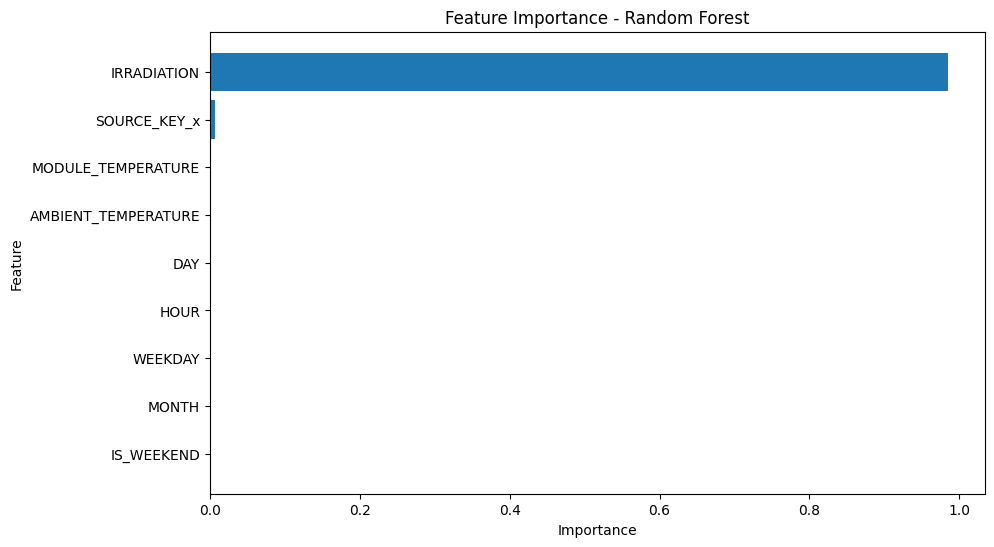

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

# Feature Importance Analysis

Feature importance was evaluated using the **Random Forest Regressor** to understand which variables contribute the most to predicting **AC Power**.

## Observations

- **Irradiation** is the most influential feature, contributing approximately **98.5%** of the total importance.
- **Inverter ID (SOURCE_KEY_x)** has a small influence, indicating slight performance differences among individual inverters.
- **Module Temperature** and **Ambient Temperature** have a minor impact on power generation.
- Time-based features such as **Hour**, **Day**, **Weekday**, **Month**, and **Is Weekend** contribute only slightly to the prediction.
- **Plant ID** has zero importance because the dataset contains data from only one solar plant.

## Business Insight

The analysis shows that **solar irradiation is the primary factor affecting AC power generation**. As the intensity of sunlight increases, the solar panels produce more electrical power. Temperature and inverter-specific characteristics also influence the output, but their contribution is much smaller compared to irradiation.

## Modeling Decision

To build a more meaningful predictive model, the following features were removed before training:
- **DC_POWER** (highly correlated with AC_POWER)
- **DAILY_YIELD**
- **TOTAL_YIELD**
- **SOURCE_KEY_y** (weather station identifier)
- **PLANT_ID** (constant value for all records)

Removing these features prevented the model from relying on information that is directly related to the target variable or does not provide useful predictive information. This allowed the model to learn the relationship between environmental conditions and solar power generation more effectively.

## Conclusion

Among all the evaluated models, the **Random Forest Regressor** achieved the best performance. The feature importance analysis confirms that **irradiation is the dominant factor influencing AC power generation**, which is consistent with the real-world behavior of photovoltaic (PV) systems.